In [ ]:
import os
import sys
import glob 
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import zscore
from scipy.signal import detrend as scipy_detrend
import matplotlib.pyplot as plt
import math
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import statsmodels.formula.api as smf

# 2.1 Cognitive load alters performance differently across subtasks

First we will print out the LME tables for accuracy and reaction time for both the baseline and experimental blocks. This full table is reported in Supplementary Material

In [ ]:
# ---------- Config ----------
EXP_CSV = "data/performance/performance_exp.csv"
BSL_CSV = "data/performance/performance_bsl.csv"

CONDITION_ORDER = ["L", "M", "H"]
GROUP_COL = "participant"
COND_COL = "condition"

ACCURACY_COLS = [
    "track_point_accuracy",
    "resman_point_accuracy",
    "sysmon_point_accuracy",
    "comms_point_accuracy",
]

RT_COLS = [
    ("mean_sysmon_response_time", "System Monitoring RT (ms)"),
    ("mean_comms_response_time", "Communications RT (ms)"),  
]

PRETTY = {
    "track_point_accuracy": "Tracking accuracy",
    "resman_point_accuracy": "Resource Management accuracy",
    "sysmon_point_accuracy": "System Monitoring accuracy",
    "comms_point_accuracy": "Communications accuracy",
}

# ---------- Helpers ----------
def ensure_condition_order(df, cond_col=COND_COL, order=CONDITION_ORDER):
    df = df.copy()
    df[cond_col] = df[cond_col].astype(str).str.strip()
    df[cond_col] = pd.Categorical(df[cond_col], categories=order, ordered=True)
    return df

def stats_norm_cdf(x):
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def erf(x):
    import math
    return math.erf(x)

def mixedlm_contrast(df, dv, a, b, group_col=GROUP_COL, cond_col=COND_COL):
    """
    MixedLM with random intercepts for participants. Contrast b vs a.
    Returns beta, z, p, n
    """
    sub = df[df[cond_col].isin([a, b])].copy()
    sub = sub.dropna(subset=[dv, group_col, cond_col])
    if sub.empty:
        return np.nan, np.nan, np.nan, 0

    # set reference = a
    sub[cond_col] = sub[cond_col].cat.remove_unused_categories()
    sub[cond_col] = sub[cond_col].cat.reorder_categories([a, b], ordered=True)

    try:
        model = smf.mixedlm(f"{dv} ~ C({cond_col})", data=sub, groups=sub[group_col])
        res = model.fit(reml=False, method="lbfgs", maxiter=200, disp=False)
    except Exception:
        try:
            model = smf.mixedlm(f"{dv} ~ C({cond_col})", data=sub, groups=sub[group_col])
            res = model.fit(reml=False, method="nm", maxiter=400, disp=False)
        except Exception:
            return np.nan, np.nan, np.nan, len(sub)

    name = f"C({cond_col})[T.{b}]"
    if name not in res.params.index:
        return np.nan, np.nan, np.nan, len(sub)

    beta = res.params[name]
    se = res.bse[name]
    z = beta / se if se > 0 else np.nan
    p = 2 * (1 - stats_norm_cdf(abs(z))) if np.isfinite(z) else np.nan
    return float(beta), float(z), float(p), len(sub)

def fmt_p_latex(p):
    if (p is None) or (not np.isfinite(p)):
        return "NA"
    return "$< .001$" if p < 0.001 else f"{p:.3f}"

def fmt_b(beta):
    return "NA" if (beta is None or (not np.isfinite(beta))) else f"{beta:.3f}"

def pair_cell(beta, p):
    if (beta is None) or (not np.isfinite(beta)) or (p is None) or (not np.isfinite(p)):
        return "NA"
    return f"{fmt_b(beta)}, {fmt_p_latex(p)}"

def table_contrasts(df, accuracy_cols, rt_cols, label_prefix):
    """
    Build a LaTeX table with columns:
      Metric | L–M (β, p) | M–H (β, p) | L–H (β, p)
    """
    rows = []
    # Accuracy
    for dv in accuracy_cols:
        metric = PRETTY.get(dv, dv)
        b_lm, _, p_lm, _ = mixedlm_contrast(df, dv, "L", "M")
        b_mh, _, p_mh, _ = mixedlm_contrast(df, dv, "M", "H")
        b_lh, _, p_lh, _ = mixedlm_contrast(df, dv, "L", "H")
        rows.append([
            metric,
            pair_cell(b_lm, p_lm),
            pair_cell(b_mh, p_mh),
            pair_cell(b_lh, p_lh),
        ])

    # RT
    for dv, pretty in rt_cols:
        b_lm, _, p_lm, _ = mixedlm_contrast(df, dv, "L", "M")
        b_mh, _, p_mh, _ = mixedlm_contrast(df, dv, "M", "H")
        b_lh, _, p_lh, _ = mixedlm_contrast(df, dv, "L", "H")
        rows.append([
            pretty,
            pair_cell(b_lm, p_lm),
            pair_cell(b_mh, p_mh),
            pair_cell(b_lh, p_lh),
        ])

    out = pd.DataFrame(rows, columns=[
        "Metric",
        "L–M (β, p)",
        "M–H (β, p)",
        "L–H (β, p)",
    ])
    print("\n" + "="*80)
    print(f"LaTeX: {label_prefix} (Accuracy & RT)")
    print("="*80)
    print(out.to_latex(index=False, escape=False,
                       caption=f"{label_prefix}: L–M, M–H, and L–H contrasts (β, p).",
                       label=f"tab:{label_prefix.lower().replace(' ', '_')}",
                       longtable=False))
    return out

# ---------- Main ----------
def run():
    exp = pd.read_csv(EXP_CSV)
    bsl = pd.read_csv(BSL_CSV)
    nasa = pd.read_csv(NASA_CSV)

    exp = ensure_condition_order(exp)
    bsl = ensure_condition_order(bsl)
    nasa = ensure_condition_order(nasa)

    # Convert Communications RT to ms
    if "mean_comms_response_time" in exp.columns:
        exp["mean_comms_response_time"] = exp["mean_comms_response_time"] * 1000.0
    if "mean_comms_response_time" in bsl.columns:
        bsl["mean_comms_response_time"] = bsl["mean_comms_response_time"] * 1000.0

    # Experimental table
    table_contrasts(exp, ACCURACY_COLS, RT_COLS, label_prefix="Experimental blocks")

    # Baseline table
    table_contrasts(bsl, ACCURACY_COLS, RT_COLS, label_prefix="Baseline blocks")

if __name__ == "__main__":
    run()


Now we will print out the results for the subjective scale ratings (NASA-TLX). These were administered at the end of every experimental block. We then computed within-subject pearson correlations between subjective ratings and subtask performance. These correlations were only computed for the experimental blocks.

In [ ]:
try:
    from scipy.stats import pearsonr
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ---- Config ----
EXP_CSV = "data/performance/performance_exp.csv"
NASA_CSV = "data/performance/aggregated_nasatlx.csv"
GROUP_COL = "participant"
COND_COL = "condition"
CONDITION_ORDER = ["L", "M", "H"]

ACCURACY_COLS = [
    "track_point_accuracy",
    "resman_point_accuracy",
    "sysmon_point_accuracy",
    "comms_point_accuracy",
]

TLX_SUBSCALES = [
    "mental_demand",
    "physical_demand",
    "time_pressure",
    "performance",
    "effort",
    "frustration",
]

def ensure_condition_order(df, cond_col=COND_COL, order=CONDITION_ORDER):
    df = df.copy()
    df[cond_col] = df[cond_col].astype(str).str.strip()
    df[cond_col] = pd.Categorical(df[cond_col], categories=order, ordered=True)
    return df

def stats_norm_cdf(x):
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def erf(x):
    import math
    return math.erf(x)

def p_fmt_latex(p):
    if p is None or not np.isfinite(p):
        return "NA"
    return "$< .001$" if p < 0.001 else f"{p:.3f}"

def b_fmt(beta):
    return "NA" if (beta is None or not np.isfinite(beta)) else f"{beta:.3f}"

def pair_cell(beta, p):
    if (beta is None or not np.isfinite(beta)) or (p is None or not np.isfinite(p)):
        return "NA"
    return f"{b_fmt(beta)}, {p_fmt_latex(p)}"

def mixedlm_contrast(df, dv, a, b, group_col=GROUP_COL, cond_col=COND_COL):
    """
    MixedLM with random intercepts for participants. Contrast b vs a.
    Returns beta, z, p, n
    """
    sub = df[df[cond_col].isin([a, b])].copy()
    sub = sub.dropna(subset=[dv, group_col, cond_col])
    if sub.empty:
        return np.nan, np.nan, np.nan, 0

    sub[cond_col] = sub[cond_col].cat.remove_unused_categories()
    sub[cond_col] = sub[cond_col].cat.reorder_categories([a, b], ordered=True)

    try:
        model = smf.mixedlm(f"{dv} ~ C({cond_col})", data=sub, groups=sub[group_col])
        res = model.fit(reml=False, method="lbfgs", maxiter=200, disp=False)
    except Exception:
        try:
            model = smf.mixedlm(f"{dv} ~ C({cond_col})", data=sub, groups=sub[group_col])
            res = model.fit(reml=False, method="nm", maxiter=400, disp=False)
        except Exception:
            return np.nan, np.nan, np.nan, len(sub)

    name = f"C({cond_col})[T.{b}]"
    if name not in res.params.index:
        return np.nan, np.nan, np.nan, len(sub)

    beta = res.params[name]
    se = res.bse[name]
    z = beta / se if se > 0 else np.nan
    p = 2 * (1 - stats_norm_cdf(abs(z))) if np.isfinite(z) else np.nan
    return float(beta), float(z), float(p), len(sub)

def within_subject_corr(df, x, y, subject=GROUP_COL):
    """
    Repeated-measures (within-subject) correlation via demeaning:
      1) subtract each subject's mean from both x and y
      2) Pearson r on the pooled residuals
    Returns (r, p, n)
    """
    sub = df.dropna(subset=[x, y, subject]).copy()
    if sub.empty:
        return np.nan, np.nan, 0

    # demean within participant
    sub[x + "_resid"] = sub[x] - sub.groupby(subject)[x].transform("mean")
    sub[y + "_resid"] = sub[y] - sub.groupby(subject)[y].transform("mean")

    xr = sub[x + "_resid"].values
    yr = sub[y + "_resid"].values

    # If scipy is available, use it. Otherwise compute r and approximate p (normal approx).
    r = np.corrcoef(xr, yr)[0, 1] if xr.size > 1 else np.nan
    n = len(xr)
    if not np.isfinite(r):
        return np.nan, np.nan, n

    if _HAVE_SCIPY:
        # pearsonr gives two-sided p
        r_s, p_s = pearsonr(xr, yr)
        return float(r_s), float(p_s), n
    else:
        # Fallback: large-sample normal approximation for p-value
        # (conservative; for publication use SciPy)
        z = 0.5 * np.log((1 + r) / (1 - r)) * np.sqrt(n - 3) if (n > 3 and abs(r) < 1) else np.nan
        p = 2 * (1 - stats_norm_cdf(abs(z))) if np.isfinite(z) else np.nan
        return float(r), float(p), n

# ---- Load data (experimental only) ----
exp = pd.read_csv(EXP_CSV)
nasa = pd.read_csv(NASA_CSV)

exp = ensure_condition_order(exp)
nasa = ensure_condition_order(nasa)

# TLX total as SUM of six subscales
nasa = nasa.copy()
nasa["tlx_total"] = nasa[TLX_SUBSCALES].sum(axis=1)

# Merge EXP + NASA on participant + condition for correlations
merged = exp.merge(
    nasa[[GROUP_COL, COND_COL] + TLX_SUBSCALES + ["tlx_total"]],
    on=[GROUP_COL, COND_COL],
    how="inner"
)

# =========================
# TABLE 1: LME for TLX subscales + total (L–M, M–H, L–H)
# =========================
def build_tlx_lme_table(nasa_df):
    metrics = TLX_SUBSCALES + ["tlx_total"]
    rows = []
    for dv in metrics:
        b_lm, _, p_lm, _ = mixedlm_contrast(nasa_df, dv, "L", "M")
        b_mh, _, p_mh, _ = mixedlm_contrast(nasa_df, dv, "M", "H")
        b_lh, _, p_lh, _ = mixedlm_contrast(nasa_df, dv, "L", "H")
        pretty_name = dv if dv != "tlx_total" else "TLX total (sum)"
        rows.append([
            pretty_name,
            pair_cell(b_lm, p_lm),
            pair_cell(b_mh, p_mh),
            pair_cell(b_lh, p_lh),
        ])

    df_out = pd.DataFrame(rows, columns=[
        "Metric",
        "L–M (β, p)",
        "M–H (β, p)",
        "L–H (β, p)",
    ])

    print("\n" + "="*80)
    print("LaTeX: NASA-TLX LME contrasts (experimental blocks only)")
    print("="*80)
    print(df_out.to_latex(
        index=False,
        escape=False,
        caption="NASA-TLX subscales and total: linear mixed-effects contrasts across load levels (experimental blocks).",
        label="tab:tlx_lme_contrasts",
        longtable=False
    ))
    return df_out

_ = build_tlx_lme_table(nasa)

# =========================
# TABLE 2: Within-subject correlations (accuracy ↔ TLX subscales + total)
# =========================
def build_within_subject_corr_table(merged_df):
    tlx_vars = TLX_SUBSCALES + ["tlx_total"]
    rows = []
    row_names = []

    for acc in ACCURACY_COLS:
        row = []
        for tlx in tlx_vars:
            r, p, n = within_subject_corr(merged_df, acc, tlx, subject=GROUP_COL)
            cell = "NA" if not np.isfinite(r) or (p is None) else f"{r:.3f}, {p_fmt_latex(p)}"
            row.append(cell)
        pretty_acc = {
            "track_point_accuracy": "Tracking accuracy",
            "resman_point_accuracy": "Resource Mgmt accuracy",
            "sysmon_point_accuracy": "System Monitoring accuracy",
            "comms_point_accuracy": "Communications accuracy",
        }.get(acc, acc)
        rows.append(row)
        row_names.append(pretty_acc)

    corr_df = pd.DataFrame(
        rows,
        columns=[c.replace("_", "\\_") for c in tlx_vars],
        index=row_names
    ).reset_index().rename(columns={"index": "Performance metric"})

    print("\n" + "="*80)
    print("LaTeX: Within-subject correlations (accuracy vs. NASA-TLX; experimental only)")
    print("="*80)
    print(corr_df.to_latex(
        index=False,
        escape=False,
        caption="Within-subject (demeaned) correlations between subtask accuracy and NASA-TLX subscales (and total) in experimental blocks.",
        label="tab:tlx_within_subject_corrs",
        longtable=False
    ))
    return corr_df

_ = build_within_subject_corr_table(merged)


Now we will create the bars for accuracy and reaction time that make up Figure 1. The correlation matrices in Figure 1 are made below in 2.2 

In [ ]:
# === Load data from the performance CSVs ===
exp = pd.read_csv("data/performance/performance_exp.csv")
bsl = pd.read_csv("data/performance/performance_bsl.csv")

# Tag sessions (to match your 'Pre' vs 'Main' plots)
exp["session"] = "Main"
bsl["session"] = "Pre"

# === Harmonize condition labels ===
cond_map = {'L': 'Low', 'M': 'Moderate', 'H': 'High'}
for df in (exp, bsl):
    df['condition'] = df['condition'].map(cond_map)
    df['session'] = df['session'].str.lower()
    df['load_level'] = pd.Categorical(df['condition'], categories=['Low', 'Moderate', 'High'], ordered=True)

# === Fix RT units ===
for df in (exp, bsl):
    sysmon_ms = df["mean_sysmon_response_time"]  # already ms
    comms_ms = df["mean_comms_response_time"] * 1000.0  # s → ms
    df["mean_rt"] = (sysmon_ms + comms_ms) / 2.0 / 1000.0  # seconds

# === Task mapping ===
task_cols = {
    'track_point_accuracy': 'Tracking',
    'resman_point_accuracy': 'Resource Management',
    'sysmon_point_accuracy': 'System Monitoring',
    'comms_point_accuracy': 'Communications',
    'mean_rt': 'Mean RT'
}

def prep_long(df):
    long_df = df.melt(
        id_vars=['participant', 'load_level'],
        value_vars=task_cols.keys(),
        var_name='subtask',
        value_name='value'
    )
    long_df['subtask'] = long_df['subtask'].map(task_cols)
    long_df['value'] = pd.to_numeric(long_df['value'], errors='coerce')
    return (
        long_df.groupby(['participant', 'load_level', 'subtask'])['value']
        .mean().reset_index()
    )

exp_long = prep_long(exp)
bsl_long = prep_long(bsl)

# === Summary stats function ===
def summarise(df):
    summary = (
        df.groupby(['subtask', 'load_level'])['value']
        .agg(['mean', 'std', 'count']).reset_index()
    )
    summary['sem'] = summary['std'] / np.sqrt(summary['count'])
    summary['load_level'] = summary['load_level'].map({'Low': 'L', 'Moderate': 'M', 'High': 'H'})
    summary['load_level'] = pd.Categorical(summary['load_level'], categories=['L', 'M', 'H'], ordered=True)
    return summary

exp_sum = summarise(exp_long)
bsl_sum = summarise(bsl_long)

# === Color palette and subtasks ===
palette = {'L': '#4575b4', 'M': '#ffffbf', 'H': '#d73027'}
subtasks = ['Tracking', 'Resource Management', 'System Monitoring', 'Communications', 'Mean RT']
# === Create combined figure ===
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4), sharey=False)

for col_idx, subtask in enumerate(subtasks):
    for row_idx, (sess_sum, sess_label) in enumerate(zip([bsl_sum, exp_sum], ['Baseline', 'Experimental'])):
        ax = axes[row_idx, col_idx]
        sub_df = sess_sum[sess_sum['subtask'] == subtask]

        # Convert RT to ms if needed
        if subtask == 'Mean RT':
            means = sub_df['mean'] * 1000  # now in ms
            sems = sub_df['sem'] * 1000
        else:
            means = sub_df['mean'] * 100  # accuracy %
            sems = sub_df['sem'] * 100

        colors = [palette[l] for l in sub_df['load_level']]

        ax.bar(
            sub_df['load_level'].cat.codes,
            means,
            yerr=sems,
            capsize=3,
            color=colors,
            edgecolor='black',
            linewidth=1
        )

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(sub_df['load_level'])
        ax.tick_params(axis='x', length=3)

        # y-limits and nicely rounded tick marks
        if subtask == 'Mean RT':
            ax.set_ylim(500, 3800)
            ax.set_yticks([500, 1250, 2000, 2750, 3500])
        else:
            ax.set_ylim(30, 110)
            ax.set_yticks([40, 60, 80, 100])

        # shorter hash marks, no grid lines
        ax.tick_params(axis='y', length=3)

        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')

fig.tight_layout()
fig.savefig("figs/figure_1_perf_corr/task_metrics/combined_accuracy_rt.svg", bbox_inches='tight')
print("[✓] Saved figure")

# 2.2 Subtask performance patterns remain stable across time

First, we will calculate pearson correlations between baseline and experimental. The results presented in the text include all data (including outliers) shown below:

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, zscore
import statsmodels.formula.api as smf

# === Load data from separate files
df_pre = pd.read_csv("data/performance/performance_bsl.csv")
df_main = pd.read_csv("data/performance/performance_exp.csv")

# Ensure correct types
for df in [df_pre, df_main]:
    df['participant'] = df['participant'].astype(str)
    df['load_level'] = df['condition'].map({'L': 'Low', 'M': 'Moderate', 'H': 'High'})
    df['load_level'] = pd.Categorical(df['load_level'], categories=['Low', 'Moderate', 'High'], ordered=True)
    df['bin_group'] = df['window_start'].astype(str)

# === Compute participant-level means per task in pre and main
pre_agg = df_pre.groupby('participant')[
    ['track_point_accuracy', 'resman_point_accuracy', 'sysmon_point_accuracy', 'comms_point_accuracy']
].mean().add_suffix('_pre')

main_agg = df_main.groupby('participant')[
    ['track_point_accuracy', 'resman_point_accuracy', 'sysmon_point_accuracy', 'comms_point_accuracy']
].mean().add_suffix('_main')

# Merge pre and main into one DataFrame
pivoted = pd.concat([pre_agg, main_agg], axis=1).dropna()

# Compute overall accuracy
pivoted['overall_pre'] = pivoted[[c for c in pivoted.columns if c.endswith('_pre')]].mean(axis=1)
pivoted['overall_main'] = pivoted[[c for c in pivoted.columns if c.endswith('_main')]].mean(axis=1)

# === Pearson correlations
task_map = {
    'track': 'track_point_accuracy',
    'resman': 'resman_point_accuracy',
    'sysmon': 'sysmon_point_accuracy',
    'comms': 'comms_point_accuracy',
    'overall': 'overall'
}

print("\n=== Pearson Correlations (Pre vs. Main) ===")
print("\n=== Pearson Correlations (Pre vs. Main) ===")
for task, prefix in task_map.items():
    pre = f'{prefix}_pre'
    main = f'{prefix}_main'

    valid = pivoted[[pre, main]].dropna()

    if len(valid) >= 2:
        r, p = pearsonr(valid[pre], valid[main])
        print(f"{task.title()} accuracy: r = {r:.3f}, p = {p:.3f} (n = {len(valid)})")
    else:
        print(f"{task.title()} accuracy: Not enough valid data.")


The table in the appendix includes outliers as calculated below

In [ ]:
# === Load data from separate files
df_pre = pd.read_csv("data/performance/performance_bsl.csv")
df_main = pd.read_csv("data/performance/performance_exp.csv")

# Ensure correct types
for df in [df_pre, df_main]:
    df['participant'] = df['participant'].astype(str)
    df['load_level'] = df['condition'].map({'L': 'Low', 'M': 'Moderate', 'H': 'High'})
    df['load_level'] = pd.Categorical(df['load_level'], categories=['Low', 'Moderate', 'High'], ordered=True)
    df['bin_group'] = df['window_start'].astype(str)

# === Compute participant-level means per task in pre and main
pre_agg = df_pre.groupby('participant')[
    ['track_point_accuracy', 'resman_point_accuracy', 'sysmon_point_accuracy', 'comms_point_accuracy']
].mean().add_suffix('_pre')

main_agg = df_main.groupby('participant')[
    ['track_point_accuracy', 'resman_point_accuracy', 'sysmon_point_accuracy', 'comms_point_accuracy']
].mean().add_suffix('_main')

# Merge pre and main into one DataFrame
pivoted = pd.concat([pre_agg, main_agg], axis=1).dropna()

# Compute overall accuracy
pivoted['overall_pre'] = pivoted[[c for c in pivoted.columns if c.endswith('_pre')]].mean(axis=1)
pivoted['overall_main'] = pivoted[[c for c in pivoted.columns if c.endswith('_main')]].mean(axis=1)

# === Pearson correlations with 3 SD filter
task_map = {
    'track': 'track_point_accuracy',
    'resman': 'resman_point_accuracy',
    'sysmon': 'sysmon_point_accuracy',
    'comms': 'comms_point_accuracy',
    'overall': 'overall'
}

results = []
for task, prefix in task_map.items():
    pre = f'{prefix}_pre'
    main = f'{prefix}_main'
    valid = pivoted[[pre, main]].dropna()

    if len(valid) >= 2:
        zs = pd.DataFrame(zscore(valid[[pre, main]]), columns=[pre, main], index=valid.index)
        keep_mask = (zs[pre].abs() < 3) & (zs[main].abs() < 3)
        filtered = valid[keep_mask]
        if len(filtered) >= 2:
            r, p = pearsonr(filtered[pre], filtered[main])
            results.append({
                'Task': task.title(),
                'r': f"{r:.3f}",
                'p': f"{p:.3f}",
                'n': len(filtered)
            })
        else:
            results.append({'Task': task.title(), 'r': 'NA', 'p': 'NA', 'n': len(filtered)})
    else:
        results.append({'Task': task.title(), 'r': 'NA', 'p': 'NA', 'n': len(valid)})

# === Create DataFrame for LaTeX export
results_df = pd.DataFrame(results)

# Print LaTeX table
print(results_df.to_latex(
    index=False,
    caption="Pearson correlations between baseline and experimental session accuracies (outliers >3 SD removed).",
    label="tab:correlations"
))


Now we will plot the pearson correlation matrices for within blocks (baseline x baseline/ experimental x experimental) and between blocks (experimental x baseline)

In [ ]:
# --- IO ---
EXP_CSV = "data/performance/performance_exp.csv"
BSL_CSV = "data/performance/performance_bsl.csv"
os.makedirs("figs", exist_ok=True)

# --- Load & harmonize ---
exp = pd.read_csv(EXP_CSV)
bsl = pd.read_csv(BSL_CSV)

for df in (exp, bsl):
    df["participant"] = df["participant"].astype(str)
    df["condition"] = df["condition"].astype(str).str.strip()

exp["session"] = "main"
bsl["session"] = "pre"

# Subtask rename to short labels
task_cols = {
    "track_point_accuracy": "Track",
    "resman_point_accuracy": "ResMan",
    "sysmon_point_accuracy": "SysMon",
    "comms_point_accuracy": "Comms",
}
exp = exp.rename(columns=task_cols)
bsl = bsl.rename(columns=task_cols)

loads = ["H", "M", "L"]  # display order

def make_wide(df_session):
    """
    Returns wide matrix: index=participant, columns=MultiIndex(levels=[condition, subtask]),
    values = mean over windows.
    """
    grouped = (
        df_session
        .groupby(["participant", "condition"])[list(task_cols.values())]
        .mean()
    )
    wide = grouped.unstack("condition")                  # inner level is condition
    wide = wide.swaplevel(0, 1, axis=1)                 # outer=condition, inner=subtask
    want_cols = pd.MultiIndex.from_product([loads, list(task_cols.values())])
    wide = wide.reindex(columns=want_cols)
    return wide

base_df = make_wide(bsl)
main_df = make_wide(exp)

# Keep common participants only
common = base_df.index.intersection(main_df.index)
base_df = base_df.loc[common]
main_df = main_df.loc[common]

# --- Correlations with p-values ---
def corr_with_pvalues(df1, df2=None):
    """Return (r_matrix, p_matrix) for df1 vs df2 (or df1 if df2=None). Aligns on index."""
    cols1 = df1.columns
    cols2 = df2.columns if df2 is not None else cols1

    r = pd.DataFrame(index=cols1, columns=cols2, dtype=float)
    p = pd.DataFrame(index=cols1, columns=cols2, dtype=float)

    for c1 in cols1:
        x = df1[c1]
        for c2 in cols2:
            y = (df2[c2] if df2 is not None else df1[c2])
            mask = x.notna() & y.notna()
            if mask.sum() > 2:
                rv, pv = pearsonr(x[mask], y[mask])
            else:
                rv, pv = np.nan, np.nan
            r.loc[c1, c2] = rv
            p.loc[c1, c2] = pv
    return r, p

base_corr,  base_p  = corr_with_pvalues(base_df)
main_corr,  main_p  = corr_with_pvalues(main_df)
cross_corr, cross_p = corr_with_pvalues(base_df, main_df)

def format_subtask_labels(columns):
    # Show only subtask (not condition) to keep labels compact
    return [task for (_, task) in columns]

def significance_mask(p_matrix, alpha=0.05):
    mask = p_matrix.copy()
    # remove diagonal when square
    if mask.shape[0] == mask.shape[1]:
        for i in range(len(mask)):
            mask.iat[i, i] = np.nan
    return mask.applymap(lambda pv: "*" if pd.notnull(pv) and pv < alpha else "")

# --- Plot three heatmaps ---
sns.set_style("white")
sns.set_context("paper", font_scale=1.1)

matrices = [
    (base_corr, base_p,  "baseline_corr_heatmap.svg",      "Baseline (Pre)"),
    (main_corr, main_p,  "experimental_corr_heatmap.svg",  "Experimental (Main)"),
    (cross_corr, cross_p,"cross_corr_heatmap.svg",         "Cross-session (Baseline vs Experimental)"),
]

for corr_matrix, p_matrix, filename, _title in matrices:
    # mirror column order for nicer layout (optional)
    corr_matrix = corr_matrix[corr_matrix.columns[::-1]]
    p_matrix    = p_matrix[p_matrix.columns[::-1]]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"aspect": "equal"})

    sns.heatmap(
        corr_matrix,
        ax=ax,
        cmap="RdYlBu_r",
        vmin=0, vmax=1,
        linewidths=0.5, linecolor="black",
        xticklabels=format_subtask_labels(corr_matrix.columns),
        yticklabels=format_subtask_labels(corr_matrix.index),
        cbar=True,
        annot=significance_mask(p_matrix),
        fmt="",
        annot_kws={"size": 14, "weight": "bold", "color": "black"}
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.tick_params(axis="x", labelrotation=90, labelsize=12)
    ax.tick_params(axis="y", labelrotation=0,  labelsize=12)

    fig.tight_layout()
    fig.savefig(f"figs/{filename}", bbox_inches="tight")
    plt.close(fig)
    print(f"[✓] Saved: figs/{filename} (with significance markers)")


# 2.3 Facial and gaze kinematics vary with task load

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from collections import defaultdict

DATA_FILE = "data/linear_pose_metrics/baseline_pose_metrics.csv"
OUTPUT_FILE = "bsl_pose_lin_table.tex"

df = pd.read_csv(DATA_FILE)

# EXCLUDE ALL NON-METRIC COLUMNS
NON_METRIC_COLS = {
    'file', 'participant', 'condition', 'window_index', 'window_start_s', 'window_end_s'
}
metric_cols = [c for c in df.columns if c not in NON_METRIC_COLS]

# categorical base = L
df['condition'] = pd.Categorical(df['condition'], categories=['L', 'M', 'H'], ordered=True)

def split_metric_name(name: str):
    # cosmetic renaming
    name = (name.replace("avg", "Average")
                .replace("dist", "Amplitude")
                .replace("mean_abs_", "")
                .replace("mean_abs", "")
                .replace("_", " ")
                .title())
    parts = name.split()
    if len(parts) < 2:
        return name, ""
    region = " ".join(parts[:-1])
    metric = parts[-1]
    return region, metric

grouped_rows = defaultdict(list)

modeled, skipped = 0, 0

for metric in metric_cols:
    # ensure numeric
    if not pd.api.types.is_numeric_dtype(df[metric]):
        skipped += 1
        print(f"[SKIP non-numeric] {metric}")
        continue

    temp_df = df[['participant', 'condition', metric]].dropna()

    # require all three levels present overall
    if not {'L','M','H'}.issubset(set(temp_df['condition'].unique())):
        skipped += 1
        print(f"[SKIP missing levels] {metric}")
        continue

    try:
        # Random intercept by participant; explicit REML + optimizer
        m_l = smf.mixedlm(f"{metric} ~ condition", data=temp_df,
                          groups=temp_df['participant'])
        r_l = m_l.fit(reml=True, method='lbfgs', maxiter=4000)

        # M vs H subset (baseline M)
        temp_df_hm = temp_df[temp_df['condition'].isin(['M','H'])].copy()
        temp_df_hm['condition'] = pd.Categorical(temp_df_hm['condition'],
                                                 categories=['M','H'], ordered=True)
        m_hm = smf.mixedlm(f"{metric} ~ condition", data=temp_df_hm,
                           groups=temp_df_hm['participant'])
        r_hm = m_hm.fit(reml=True, method='lbfgs', maxiter=4000)

        def fmt(beta, p):
            b = f"$\\beta = {beta:.3f}$" if pd.notnull(beta) else "--"
            p = (r"$p < .001$" if pd.notnull(p) and p < 0.001
                 else f"$p = {p:.3f}$" if pd.notnull(p) else "--")
            return b, p

        b_m, p_m = fmt(r_l.params.get('condition[T.M]'), r_l.pvalues.get('condition[T.M]'))
        b_h, p_h = fmt(r_l.params.get('condition[T.H]'), r_l.pvalues.get('condition[T.H]'))
        b_hm, p_hm = fmt(r_hm.params.get('condition[T.H]'), r_hm.pvalues.get('condition[T.H]'))

        region, metric_type = split_metric_name(metric)
        grouped_rows[region].append((metric_type, b_m, p_m, b_h, p_h, b_hm, p_hm))
        modeled += 1

    except Exception as e:
        skipped += 1
        print(f"[SKIP error] {metric}: {e}")

# sort regions and their metrics for stable output
desired_order = ["Vel", "Acc", "Rms"]
grouped_rows[r] = sorted(grouped_rows[r],
                         key=lambda x: desired_order.index(x[0]))

latex_lines = [
    r"\begin{tabular}{llcc|cc|cc}",
    r"\toprule",
    r"Region & Metric & $\beta_{\text{M}}$ & $p_{\text{M}}$ & $\beta_{\text{H}}$ & $p_{\text{H}}$ & $\beta_{\text{H--M}}$ & $p_{\text{H--M}}$ \\",
    r"\midrule"
]

for region in sorted_regions:
    rows = grouped_rows[region]
    first = True
    for metric_type, b_m, p_m, b_h, p_h, b_hm, p_hm in rows:
        region_label = f"\\multirow{{{len(rows)}}}{{*}}{{{region}}}" if first else ""
        latex_lines.append(f"{region_label} & {metric_type} & {b_m} & {p_m} & {b_h} & {p_h} & {b_hm} & {p_hm} \\\\")
        first = False
    latex_lines.append(r"\midrule")

latex_lines += [r"\bottomrule", r"\end{tabular}"]

with open(OUTPUT_FILE, "w") as f:
    f.write("\n".join(latex_lines))

print(f"[OK] Wrote LaTeX to: {OUTPUT_FILE} | modeled={modeled}, skipped={skipped}")


# 2.4/5/6 RQA Facial, gaze, CRQA, and blink

## Output Table

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
from collections import defaultdict
from math import sqrt
from scipy.stats import norm  # for p-values

# ---- CONFIG ----
DATA_FILE   = "data/rqa/baseline_pose_rqa.csv"  # change to # experimental data if needed
OUTPUT_FILE = "baseline_rqa_table.tex" # change to # experimental output if needed

# columns that are NOT dependent variables
NON_METRIC_COLS = {
    "participant", "condition", "column",
    "window_index", "window_start", "window_end",
    "start_sample", "end_sample", "file"
}

# ---- LOAD ----
df = pd.read_csv(DATA_FILE)

def pretty_metric(name: str) -> str:
    return name.replace("_", " ").title()
# ensure ordered categories: baseline = 'L'
df["condition"] = pd.Categorical(df["condition"], categories=["L", "M", "H"], ordered=True)

# identify metric columns to model (everything numeric that's not id/timing)
metric_cols = [c for c in df.columns if c not in NON_METRIC_COLS and pd.api.types.is_numeric_dtype(df[c])]

def fmt_beta_p(beta, p):
    if not np.isfinite(beta) or not np.isfinite(p):
        return "--"
    p_txt = "<.001" if p < 0.001 else f"{p:.3f}"
    return f"{beta:.3f} ({p_txt})"

def mh_contrast_from_full(result):
    """
    Compute H–M contrast from full L/M/H model:
      params: Intercept, condition[T.M], condition[T.H]
      H–M = beta_H - beta_M
      Var(H–M) = Var(H) + Var(M) - 2*Cov(H,M)
    """
    p = result.params
    cov = result.cov_params()
    bM = p.get("condition[T.M]", np.nan)
    bH = p.get("condition[T.H]", np.nan)
    if not np.isfinite(bM) or not np.isfinite(bH):
        return np.nan, np.nan

    varM = cov.loc["condition[T.M]", "condition[T.M]"]
    varH = cov.loc["condition[T.H]", "condition[T.H]"]
    covMH = cov.loc["condition[T.M]", "condition[T.H]"]
    se = sqrt(max(varM + varH - 2.0 * covMH, 0.0))
    est = bH - bM
    if se == 0 or not np.isfinite(se):
        return est, np.nan
    z = est / se
    pval = 2.0 * norm.sf(abs(z))
    return est, pval

# collect rows: keyed by 'column' (data type) -> list of (metric_name, L–M, p, L–H, p, M–H, p)
grouped = defaultdict(list)

for col_name in sorted(df["column"].dropna().unique()):
    dsub = df[df["column"] == col_name].copy()
    # require all three levels in this subset
    if not {"L", "M", "H"}.issubset(dsub["condition"].unique()):
        continue

    for metric in metric_cols:
        # drop NaNs for this DV
        mdf = dsub[["participant", "condition", metric]].dropna()
        # still need 3 levels present post-drop
        if not {"L", "M", "H"}.issubset(mdf["condition"].unique()):
            continue
        try:
            model = smf.mixedlm(f"{metric} ~ condition", data=mdf, groups=mdf["participant"])
            res   = model.fit(method="lbfgs", reml=True, maxiter=4000)

            # L–M and L–H come directly from treatment-coded coefficients (M vs L, H vs L)
            bLM  = res.params.get("condition[T.M]", np.nan)
            pLM  = res.pvalues.get("condition[T.M]", np.nan)
            bLH  = res.params.get("condition[T.H]", np.nan)
            pLH  = res.pvalues.get("condition[T.H]", np.nan)

            # M–H from full model (H - M)
            bMH, pMH = mh_contrast_from_full(res)

            grouped[col_name].append((
                pretty_metric(metric),
                fmt_beta_p(bLM, pLM),
                fmt_beta_p(bLH, pLH),
                fmt_beta_p(bMH, pMH),
            ))
        except Exception as e:
            print(f"[SKIP] {col_name} / {metric}: {e}")

# ---- LaTeX table ----
lines = [
    r"\begin{tabular}{llccc}",
    r"\toprule",
    r"Data type & Metric & L--M & L--H & M--H \\",
    r"\midrule"
]

for col_name in sorted(grouped.keys()):
    rows = sorted(grouped[col_name], key=lambda x: x[0])  # x = (metric, LM, LH, MH)
    first = True
    for (metric, lm, lh, mh) in rows:
        left = f"\\multirow{{{len(rows)}}}{{*}}{{{col_name}}}" if first else ""
        lines.append(f"{left} & {metric} & {lm} & {lh} & {mh} \\\\")
        first = False
    lines.append(r"\midrule")

lines += [r"\bottomrule", r"\end{tabular}"]

with open(OUTPUT_FILE, "w") as f:
    f.write("\n".join(lines))

print(f"[OK] wrote {OUTPUT_FILE}")


# Pose Metrics 2x2 Figure

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_16100/3217749234.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_pose = pose.groupby("condition")[vel_col].agg(["mean", sem]).reindex(COND_ORDER)
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_16100/3217749234.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_rqa_cf = rqa_cf.groupby("condition")["perc_recur"].agg(["mean", sem]).reindex(COND_ORDER)
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_16100/3217749234.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futu

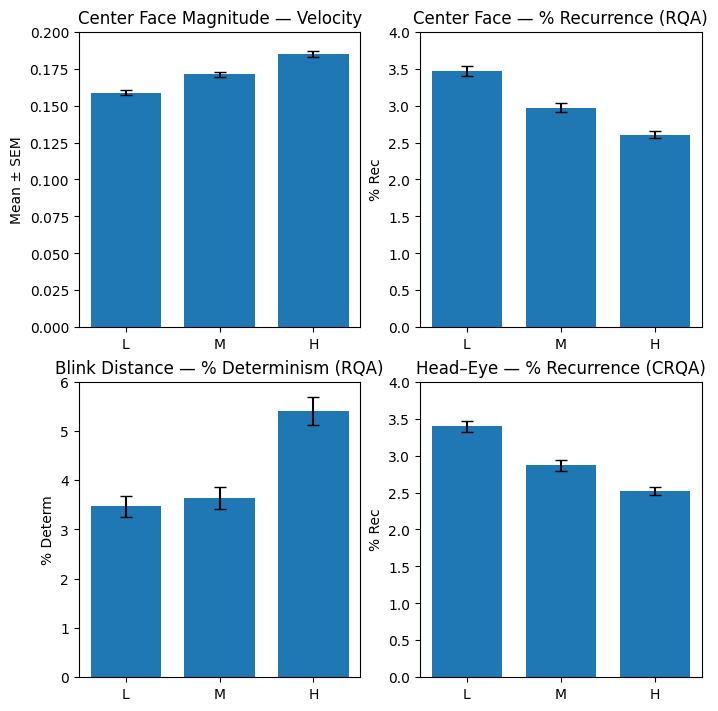

[OK] Saved plot -> figs/figure_2_pose_keypts/experimental_pose_2x2_bars.svg


In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---- Files ----
POSE_METRICS = "data/linear_pose_metrics/experimental_pose_metrics.csv"
RQA_FILE     = "data/rqa/experimental_pose_rqa.csv"
CRQA_FILE    = "data/rqa/experimental_pose_crqa_head_eye.csv"  # fallback if not merged into RQA

COND_ORDER = ["L", "M", "H"]

def ensure_condition_order(df):
    if "condition" in df.columns:
        df["condition"] = pd.Categorical(df["condition"], categories=COND_ORDER, ordered=True)
    return df

def sem(series):
    s = pd.Series(series).astype(float)
    return s.std(ddof=1) / np.sqrt(s.count())

def find_velocity_col(cols):
    """Prefer the canonical column name; fall back to fuzzy matches."""
    # canonical from your pipeline
    preferred = "center_face_magnitude_mean_abs_vel"
    if preferred in cols:
        return preferred
    # fuzzy: allow 'centre' vs 'center', allow suffix variations
    lowered = [c.lower() for c in cols]
    candidates = []
    for c in lowered:
        if ("center" in c or "centre" in c) and "face" in c and "magnitude" in c and ("mean_abs_vel" in c or c.endswith("_vel")):
            candidates.append(cols[lowered.index(c)])
    if candidates:
        return candidates[0]
    raise KeyError("Could not find a center_face_magnitude velocity column in pose metrics CSV.")

# ---------- Load data ----------
pose = pd.read_csv(POSE_METRICS)
pose = ensure_condition_order(pose)

rqa  = pd.read_csv(RQA_FILE)
rqa  = ensure_condition_order(rqa)

# Try to get CRQA from the RQA file if you previously merged it (column == 'head_eye_crqa')
crqa = None
if "column" in rqa.columns and (rqa["column"] == "head_eye_crqa").any():
    crqa = rqa[rqa["column"] == "head_eye_crqa"].copy()
else:
    # fallback to the standalone CRQA file
    if os.path.exists(CRQA_FILE):
        crqa = pd.read_csv(CRQA_FILE)
        crqa = ensure_condition_order(crqa)
    else:
        raise FileNotFoundError(
            "CRQA data not found. Either merge CRQA into the RQA CSV with column=='head_eye_crqa' "
            "or provide the standalone file at data/rqa/experimental_pose_crqa_head_eye.csv."
        )

# ---------- Prep aggregates ----------
# Top-left: center_face_magnitude velocity from pose metrics
vel_col = find_velocity_col(pose.columns)
agg_pose = pose.groupby("condition")[vel_col].agg(["mean", sem]).reindex(COND_ORDER)

# Top-right: center_face perc_recur from RQA
if "column" not in rqa.columns:
    raise KeyError("RQA file must be in long format with a 'column' field (e.g., 'center_face_magnitude').")
rqa_cf = rqa[rqa["column"] == "center_face_magnitude"].copy()
agg_rqa_cf = rqa_cf.groupby("condition")["perc_recur"].agg(["mean", sem]).reindex(COND_ORDER)

# Bottom-left: blink_dist perc_determ from RQA
rqa_blink = rqa[rqa["column"] == "blink_dist"].copy()
agg_rqa_blink = rqa_blink.groupby("condition")["perc_determ"].agg(["mean", sem]).reindex(COND_ORDER)

# Bottom-right: CRQA % recurrence (perc_recur)
agg_crqa = crqa.groupby("condition")["perc_recur"].agg(["mean", sem]).reindex(COND_ORDER)

# ---------- Plot ----------
fig, axes = plt.subplots(2, 2, figsize=(7, 7), constrained_layout=True)

def barplot(ax, agg, title, ylabel, ylim=None):
    idx = np.arange(len(COND_ORDER))
    means = agg["mean"].to_numpy(dtype=float)
    errs  = agg["sem"].to_numpy(dtype=float)
    ax.bar(idx, means, yerr=errs, capsize=4, width=0.75)
    ax.set_xticks(idx)
    ax.set_xticklabels(COND_ORDER)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlim(-0.5, len(COND_ORDER)-0.5)
    #ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    #ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    if ylim is not None:
        ax.set_ylim(ylim)

# You can tweak these per-panel limits
barplot(axes[0,0], agg_pose,      "Center Face Magnitude — Velocity",          "Mean ± SEM", (0, 0.2))
barplot(axes[0,1], agg_rqa_cf,    "Center Face — % Recurrence (RQA)",          "% Rec",      (0, 4))
barplot(axes[1,0], agg_rqa_blink, "Blink Distance — % Determinism (RQA)",      "% Determ",   (0, 6))
barplot(axes[1,1], agg_crqa,      "Head–Eye — % Recurrence (CRQA)",            "% Rec",      (0, 4))

# Save and show
os.makedirs("figs", exist_ok=True)
out_path = "figs/figure_2_pose_keypts/experimental_pose_2x2_bars.svg"
plt.savefig(out_path, dpi=300)
plt.show()
print(f"[OK] Saved plot -> {out_path}")


# 2.7/8/9 Model figures
All of the models reported/trained are run using machine_learning.ipynb. The script also has the figures.

# RQA Example

In [2]:
import pandas as pd

def find_representative_window(df, feature_column, metric, trend='decrease'):
    """
    Finds the most representative window for a given trend in RQA metrics.

    Args:
        df (pd.DataFrame): The full DataFrame with RQA results.
        feature_column (str): The specific feature to analyze (e.g., 'centre_face_magnitude').
        metric (str): The RQA metric to evaluate (e.g., 'perc_recur').
        trend (str): 'decrease' to find the largest drop from Low to High load,
                     'increase' to find the largest rise.

    Returns:
        dict: A dictionary containing the details of the most representative window.
    """
    print(f"🔍 Searching for '{feature_column}' showing the largest {trend} in '{metric}'...")

    # 1. Filter the data for the specific feature
    feature_df = df[df['column'] == feature_column].copy()
    if feature_df.empty:
        print(f"  ⚠️ Warning: No data found for feature column '{feature_column}'. Skipping.")
        return None

    # 2. Separate Low and High load conditions
    low_load_df = feature_df[feature_df['condition'] == 'L']
    high_load_df = feature_df[feature_df['condition'] == 'H']

    # 3. Merge the two conditions to compare them side-by-side for each window
    merged_df = pd.merge(
        low_load_df,
        high_load_df,
        on=['participant', 'window_index'],
        suffixes=('_low', '_high')
    )

    if merged_df.empty:
        print(f"  ⚠️ Warning: Could not find matching Low/High windows for '{feature_column}'. Skipping.")
        return None

    # 4. Calculate the difference based on the desired trend
    if trend == 'decrease':
        # We want to maximize (Low - High)
        merged_df['metric_diff'] = merged_df[f'{metric}_low'] - merged_df[f'{metric}_high']
    elif trend == 'increase':
        # We want to maximize (High - Low)
        merged_df['metric_diff'] = merged_df[f'{metric}_high'] - merged_df[f'{metric}_low']
    else:
        raise ValueError("Trend must be either 'increase' or 'decrease'.")

    # 5. Find the window with the maximum difference
    if merged_df['metric_diff'].empty or merged_df['metric_diff'].isnull().all():
        print(f"  ⚠️ Warning: No valid differences calculated for '{feature_column}'. Skipping.")
        return None
        
    best_window = merged_df.loc[merged_df['metric_diff'].idxmax()]

    # 6. Prepare and return the results
    result = {
        'feature': feature_column,
        'metric': metric,
        'trend': trend,
        'participant': int(best_window['participant']),
        'window_index': int(best_window['window_index']),
        'low_load_value': best_window[f'{metric}_low'],
        'high_load_value': best_window[f'{metric}_high'],
        'difference': best_window['metric_diff']
    }
    return result

def main():
    """
    Main function to load data and run the analysis.
    """
    try:
        # Load the CSV file
        file_path = 'data/rqa/experimental_pose_rqa.csv'
        rqa_data = pd.read_csv(file_path)
        print(f"✅ Successfully loaded data from '{file_path}'.")
    except FileNotFoundError:
        print(f"❌ Error: The file '{file_path}' was not found.")
        print("Please make sure your CSV file is in the same directory and named correctly.")
        return

    print("\n--- Analyzing Trends from Paper ---")

    # --- Trend 1: Movement Fragmentation (e.g., Centre-Face Motion) ---
    # As load increases, movement becomes less repetitive.
    # We look for the largest DECREASE in Recurrence Rate (%REC).
    # Note: Assuming 'centre_face_magnitude' is a column name. Adjust if necessary.
    fragmentation_example = find_representative_window(
        rqa_data,
        feature_column='center_face_magnitude', #<-- ADJUST if your column name is different
        metric='perc_recur',
        trend='decrease'
    )

    # --- Trend 2: Blink Structuring ---
    # As load increases, blinks become more structured and predictable.
    # We look for the largest INCREASE in Determinism (DET).
    # Note: Assuming 'blink' is a column name. Adjust if necessary.
    structuring_example = find_representative_window(
        rqa_data,
        feature_column='blink_dist', #<-- ADJUST if your column name is different
        metric='perc_determ',
        trend='increase'
    )

    print("\n--- 🏆 Most Representative Examples Found ---")

    if fragmentation_example:
        print("\n📈 Best Example of MOVEMENT FRAGMENTATION:")
        print(f"   - Feature:         {fragmentation_example['feature']}")
        print(f"   - Participant:       {fragmentation_example['participant']}")
        print(f"   - Window Index:      {fragmentation_example['window_index']}")
        print(f"   - Metric:            {fragmentation_example['metric']} (Low -> High)")
        print(f"   - Values:            {fragmentation_example['low_load_value']:.2f} -> {fragmentation_example['high_load_value']:.2f}")
        print(f"   - Change (Decrease): {fragmentation_example['difference']:.2f}")

    if structuring_example:
        print("\n📉 Best Example of BLINK STRUCTURING:")
        print(f"   - Feature:         {structuring_example['feature']}")
        print(f"   - Participant:       {structuring_example['participant']}")
        print(f"   - Window Index:      {structuring_example['window_index']}")
        print(f"   - Metric:            {structuring_example['metric']} (Low -> High)")
        print(f"   - Values:            {structuring_example['low_load_value']:.2f} -> {structuring_example['high_load_value']:.2f}")
        print(f"   - Change (Increase): {structuring_example['difference']:.2f}")

if __name__ == "__main__":
    main()


✅ Successfully loaded data from 'data/rqa/experimental_pose_rqa.csv'.

--- Analyzing Trends from Paper ---
🔍 Searching for 'center_face_magnitude' showing the largest decrease in 'perc_recur'...
🔍 Searching for 'blink_dist' showing the largest increase in 'perc_determ'...

--- 🏆 Most Representative Examples Found ---

📈 Best Example of MOVEMENT FRAGMENTATION:
   - Feature:         center_face_magnitude
   - Participant:       474
   - Window Index:      6
   - Metric:            perc_recur (Low -> High)
   - Values:            24.65 -> 3.61
   - Change (Decrease): 21.04

📉 Best Example of BLINK STRUCTURING:
   - Feature:         blink_dist
   - Participant:       410
   - Window Index:      7
   - Metric:            perc_determ (Low -> High)
   - Values:            8.00 -> 60.58
   - Change (Increase): 52.57
